✅ 模型加载成功！
✅ 分类概率：
  ➤ DEFECTED      : 0.9999
  ➤ NON-DEFECTED  : 0.0001
✅ 最终预测: DEFECTED (置信度: 100.0%)


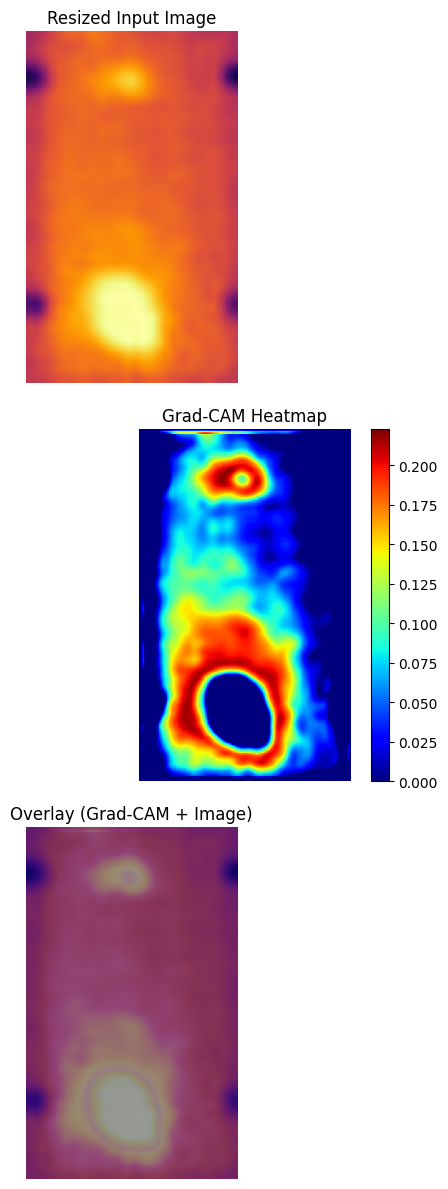

In [1]:
import tensorflow as tf
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

# -------------------------------
# 模型加载（自定义层）
class InceptionModule(tf.keras.layers.Layer):
    def __init__(self, filters, name="inception_block", **kwargs):
        super().__init__(name=name, **kwargs)
        self.filters = filters
        self.branch1 = tf.keras.Sequential([
            tf.keras.layers.Conv2D(filters[0], (1, 1), padding='same', activation='relu')
        ])
        self.branch2 = tf.keras.Sequential([
            tf.keras.layers.Conv2D(filters[1], (1, 1), padding='same', activation='relu'),
            tf.keras.layers.Conv2D(filters[2], (3, 3), padding='same', activation='relu')
        ])
        self.branch3 = tf.keras.Sequential([
            tf.keras.layers.Conv2D(filters[3], (1, 1), padding='same', activation='relu'),
            tf.keras.layers.Conv2D(filters[4], (5, 5), padding='same', activation='relu')
        ])
        self.branch4 = tf.keras.Sequential([
            tf.keras.layers.MaxPooling2D((3, 3), strides=(1, 1), padding='same'),
            tf.keras.layers.Conv2D(filters[5], (1, 1), padding='same', activation='relu')
        ])
        
    def call(self, inputs):
        return tf.keras.layers.concatenate([
            self.branch1(inputs),
            self.branch2(inputs),
            self.branch3(inputs),
            self.branch4(inputs)
        ], axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({'filters': self.filters})
        return config

class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, num_heads, key_dim, name="multihead_attn", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.Wq = tf.keras.layers.Dense(key_dim * num_heads)
        self.Wk = tf.keras.layers.Dense(key_dim * num_heads)
        self.Wv = tf.keras.layers.Dense(key_dim * num_heads)
        self.dense = tf.keras.layers.Dense(key_dim * num_heads)

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        Q = tf.reshape(self.Wq(inputs), [batch_size, -1, self.num_heads, self.key_dim])
        K = tf.reshape(self.Wk(inputs), [batch_size, -1, self.num_heads, self.key_dim])
        V = tf.reshape(self.Wv(inputs), [batch_size, -1, self.num_heads, self.key_dim])
        attention = tf.einsum('bqhd,bkhd->bhqk', Q, K) / tf.sqrt(tf.cast(self.key_dim, tf.float32))
        attention = tf.nn.softmax(attention, axis=-1)
        output = tf.einsum('bhqk,bkhd->bqhd', attention, V)
        output = tf.reshape(output, [batch_size, -1, self.num_heads * self.key_dim])
        return self.dense(output), attention

    def get_config(self):
        return {'num_heads': self.num_heads, 'key_dim': self.key_dim}

# 加载模型
model_path = "final_binary_model_v3.h5"
model = tf.keras.models.load_model(
    model_path,
    custom_objects={
        'InceptionModule': InceptionModule,
        'MultiHeadAttention': MultiHeadAttention
    }
)
print("✅ 模型加载成功！")

TARGET_WIDTH = 128   # 竖图宽
TARGET_HEIGHT = 213  # 竖图高

# -------------------------------
# 图像预处理
def preprocess_image_for_model(image):
    resized = cv2.resize(image, (TARGET_WIDTH, TARGET_HEIGHT), interpolation=cv2.INTER_CUBIC)  # 竖图 resize
    normalized = resized.astype(np.float32) / 255.0
    return np.expand_dims(normalized, axis=0), resized  # 返回预处理图 + resize原图

# Grad-CAM
def generate_grad_cam(model, img_array, target_layer_name, class_idx=None):
    grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(target_layer_name).output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if class_idx is None:
            class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + tf.keras.backend.epsilon())
    return heatmap.numpy()

def display_all_three(resized_img, heatmap):
    heatmap_resized = cv2.resize(np.uint8(255 * heatmap), (resized_img.shape[1], resized_img.shape[0]))
    heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

    if resized_img.shape[-1] == 3:
        image_bgr = cv2.cvtColor(resized_img, cv2.COLOR_RGB2BGR)
    else:
        image_bgr = cv2.cvtColor(resized_img, cv2.COLOR_GRAY2BGR)

    overlay_bgr = cv2.addWeighted(image_bgr, 0.6, heatmap_color, 0.4, 0)

    original_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    overlay_rgb = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 12))

    plt.subplot(3, 1, 1)
    plt.imshow(original_rgb)
    plt.title("Resized Input Image")
    plt.axis('off')

    plt.subplot(3, 1, 2)
    plt.imshow(heatmap, cmap='jet')
    plt.title("Grad-CAM Heatmap")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis('off')

    plt.subplot(3, 1, 3)
    plt.imshow(overlay_rgb)
    plt.title("Overlay (Grad-CAM + Image)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()


# -------------------------------
# 测试图像路径
test_image_path = r"E:\CDUT\English\7 Term\Project\model\archive\panel_cell\defected\7687.png"

try:
    # 读取并转换图像
    original_image = cv2.imread(test_image_path)
    original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

    # 预处理
    processed_input, resized_input = preprocess_image_for_model(original_image)

    # 模型预测
    prediction = model.predict(processed_input)
    confidence = prediction[0][0]
    print("✅ 分类概率：")
    print(f"  ➤ DEFECTED      : {confidence:.4f}")
    print(f"  ➤ NON-DEFECTED  : {1 - confidence:.4f}")
    
    class_name = "defected" if confidence > 0.5 else "non-defected"
    print(f"✅ 最终预测: {class_name.upper()} (置信度: {abs(confidence - 0.5) * 2:.1%})")


    # Grad-CAM
    target_layer = "inception_block"
    heatmap = generate_grad_cam(model, processed_input, target_layer)

    # 展示三图
    display_all_three(resized_input, heatmap)

except Exception as e:
    print(f"❌ 错误: {str(e)}")

In [2]:
for i, layer in enumerate(model.layers):
    print(f"{i}: {layer.name} ({layer.__class__.__name__})")


0: input_1 (InputLayer)
1: conv2d (Conv2D)
2: batch_normalization (BatchNormalization)
3: inception_block (InceptionModule)
4: max_pooling2d_1 (MaxPooling2D)
5: reshape (Reshape)
6: bidirectional (Bidirectional)
7: dropout (Dropout)
8: multihead_attn (MultiHeadAttention)
9: concatenate (Concatenate)
10: global_average_pooling1d (GlobalAveragePooling1D)
11: dense_4 (Dense)
12: dropout_1 (Dropout)
13: dense_5 (Dense)


In [3]:
from numba import cuda

cuda.select_device(0)
cuda.close()